<a href="https://colab.research.google.com/github/juliamota1/CN-unifesp/blob/main/atv1_CN_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 1 - Cálculo numérico
Julia dos Santos Mota

## 1. Objetivos

• calcular erros absoluto, relativo e percentual;

• distinguir truncamento de arredondamento;

• observar a propagação dos erros em cálculos de pressão e vazão;

• produzir gráficos que comuniquem a evolução dos erros;

• explicar por que pequenas variações geométricas podem alterar intensamente o escoamento em um nanocateter.

In [45]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


In [4]:
def truncar(numero, casas):
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

In [5]:
def erro_absoluto(valor_referencia, valor_aproximado):
  return abs(valor_referencia - valor_aproximado)

def erro_relativo(erro_absoluto, valor_referencia):
  return erro_absoluto / abs(valor_referencia)

def erro_percentual(erro_relativo):
  return 100.0 * erro_relativo

1) aproximação por truncamento e arredondamento

In [6]:
x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765

valores = [x1, x2, x3]

In [7]:
for valor_referencia in valores:

  for n in range(5):
    print("")
    valor_trunc = truncar(valor_referencia, n)

    valor_round = round(valor_referencia, n)

    erro_abs_trunc = erro_absoluto(valor_referencia, valor_trunc)
    erro_rel_trunc = erro_relativo(erro_abs_trunc, valor_referencia)
    erro_per_trunc = erro_percentual(erro_rel_trunc)


    erro_abs_round = erro_absoluto(valor_referencia, valor_round)
    erro_rel_round = erro_relativo(erro_abs_round, valor_referencia)
    erro_per_round = erro_percentual(erro_rel_round)


    print(f"Truncado: {valor_trunc}")

    print(f"Ea = {erro_abs_trunc:.10f}")
    print(f"Er = {erro_rel_trunc:.6e}")
    print(f"Ep = {erro_per_trunc:.6f}")

    print(f"Arredondado: {valor_round}")
    print(f"Ea = {erro_abs_round:.10f}")
    print(f"Er = {erro_rel_round:.6e}")
    print(f"Ep = {erro_per_round:.6f}")



Truncado: 3.0
Ea = 0.1415926500
Er = 4.507034e-02
Ep = 4.507034
Arredondado: 3.0
Ea = 0.1415926500
Er = 4.507034e-02
Ep = 4.507034

Truncado: 3.1
Ea = 0.0415926500
Er = 1.323935e-02
Ep = 1.323935
Arredondado: 3.1
Ea = 0.0415926500
Er = 1.323935e-02
Ep = 1.323935

Truncado: 3.14
Ea = 0.0015926500
Er = 5.069562e-04
Ep = 0.050696
Arredondado: 3.14
Ea = 0.0015926500
Er = 5.069562e-04
Ep = 0.050696

Truncado: 3.141
Ea = 0.0005926500
Er = 1.886464e-04
Ep = 0.018865
Arredondado: 3.142
Ea = 0.0004073500
Er = 1.296635e-04
Ep = 0.012966

Truncado: 3.1415
Ea = 0.0000926500
Er = 2.949141e-05
Ep = 0.002949
Arredondado: 3.1416
Ea = 0.0000073500
Er = 2.339578e-06
Ep = 0.000234

Truncado: 98.0
Ea = 0.7654300000
Er = 7.749979e-03
Ep = 0.774998
Arredondado: 99.0
Ea = 0.2345700000
Er = 2.375021e-03
Ep = 0.237502

Truncado: 98.7
Ea = 0.0654300000
Er = 6.624788e-04
Ep = 0.066248
Arredondado: 98.8
Ea = 0.0345700000
Er = 3.500213e-04
Ep = 0.035002

Truncado: 98.76
Ea = 0.0054300000
Er = 5.497875e-05
Ep = 0.

In [8]:
for indice, valor_referencia in enumerate(valores):

    casas_decimais = [0, 1, 2, 3, 4]

    erros_truncamento = []
    erros_arredondamento = []

    for n in casas_decimais:

        valor_truncado = truncar(valor_referencia, n)

        ea_trunc = abs(
            valor_referencia - valor_truncado
        )

        er_trunc = (
            ea_trunc / abs(valor_referencia)
        )

        ep_trunc = 100.0 * er_trunc

        print(
            f"{n:<5}"
            f"{'Truncamento':<18}"
            f"{valor_truncado:<20.8f}"
            f"{ea_trunc:<20.10f}"
            f"{er_trunc:<20.6e}"
            f"{ep_trunc:<20.6f}"
        )

        valor_arredondado = round(valor_referencia, n)

        ea_round = abs(
            valor_referencia - valor_arredondado
        )

        er_round = (
            ea_round / abs(valor_referencia)
        )

        ep_round = 100.0 * er_round

        print(
            f"{n:<5}"
            f"{'Arredondamento':<18}"
            f"{valor_arredondado:<20.8f}"
            f"{ea_round:<20.10f}"
            f"{er_round:<20.6e}"
            f"{ep_round:<20.6f}"

        )


0    Truncamento       3.00000000          0.1415926500        4.507034e-02        4.507034            
0    Arredondamento    3.00000000          0.1415926500        4.507034e-02        4.507034            
1    Truncamento       3.10000000          0.0415926500        1.323935e-02        1.323935            
1    Arredondamento    3.10000000          0.0415926500        1.323935e-02        1.323935            
2    Truncamento       3.14000000          0.0015926500        5.069562e-04        0.050696            
2    Arredondamento    3.14000000          0.0015926500        5.069562e-04        0.050696            
3    Truncamento       3.14100000          0.0005926500        1.886464e-04        0.018865            
3    Arredondamento    3.14200000          0.0004073500        1.296635e-04        0.012966            
4    Truncamento       3.14150000          0.0000926500        2.949141e-05        0.002949            
4    Arredondamento    3.14160000          0.0000073500        2

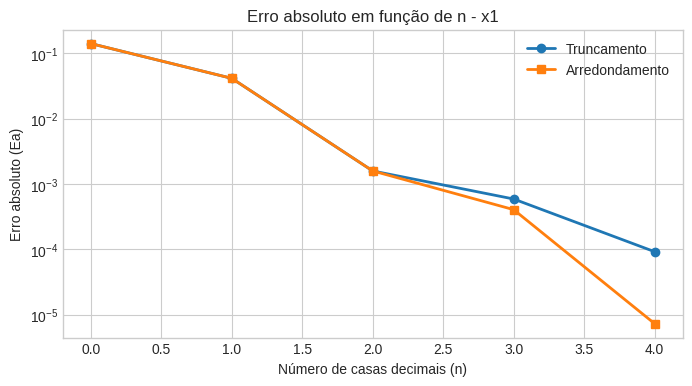

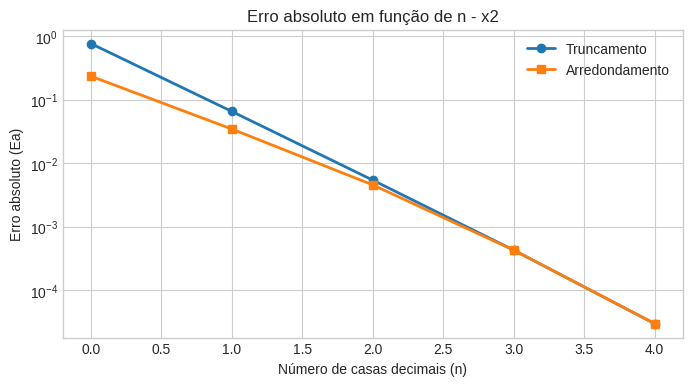

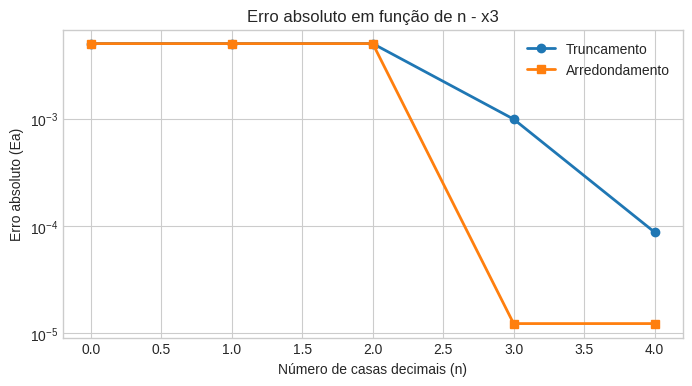

In [9]:
for indice, valor_referencia in enumerate(valores):

    casas_decimais = [0, 1, 2, 3, 4]

    erros_truncamento = []
    erros_arredondamento = []

    for n in casas_decimais:

        valor_truncado = truncar(valor_referencia, n)

        erro_trunc = abs(
            valor_referencia - valor_truncado
        )

        erros_truncamento.append(erro_trunc)


        valor_arredondado = round(valor_referencia, n)

        erro_arred = abs(
            valor_referencia - valor_arredondado
        )

        erros_arredondamento.append(erro_arred)


    plt.figure(figsize=(8, 4))

    plt.semilogy(
        casas_decimais,
        erros_truncamento,
        marker="o",
        linewidth=2,
        label="Truncamento"
    )

    plt.semilogy(
        casas_decimais,
        erros_arredondamento,
        marker="s",
        linewidth=2,
        label="Arredondamento"
    )

    plt.xlabel("Número de casas decimais (n)")
    plt.ylabel("Erro absoluto (Ea)")

    plt.title(
        f"Erro absoluto em função de n - x{indice + 1}"
    )

    plt.legend()

    plt.show()

### 5. Arredondar sempre gera erro menor que truncamento?

Sempre é menor ou igual, e é igual geralmente com poucas casas como 0, 1, 2

In [10]:
dados_originais = [121.7,
120.4,
122.1,
119.8,
121.2,
120.9,
122.4,
121.0,
120.2,
121.5 ]


In [11]:
media_referencia = np.mean(dados_originais)
print(media_referencia)

121.12


In [12]:
dados_int_round = []
for valor in dados_originais:
  valor_round = round(valor, 0)
  dados_int_round.append(valor_round)

In [13]:
dados_int_trunc = []
for valor in dados_originais:
  valor_trunc = truncar(valor, 0)
  dados_int_trunc.append(valor_trunc)

In [14]:
def calcular_estatisticas(dados):

    media = np.mean(dados)

    minimo = np.min(dados)

    maximo = np.max(dados)

    amplitude = maximo - minimo

    desvio_padrao = np.std(dados, ddof=1)

    return media, minimo, maximo, amplitude, desvio_padrao

In [15]:
series = [
    dados_originais,
    dados_int_round,
    dados_int_trunc,

]

nomes = [
    "Original",
    "Inteiro arredondado",
    "Inteiro truncado",

]

for i in range(len(series)):

    media, minimo, maximo, amplitude, desvio_padrao = calcular_estatisticas(series[i])

    print("\n", nomes[i])
    print("Média =", media)
    print("Mínimo =", minimo)
    print("Máximo =", maximo)
    print("Amplitude =", amplitude)
    print("Desvio-padrão amostral =", desvio_padrao)


 Original
Média = 121.12
Mínimo = 119.8
Máximo = 122.4
Amplitude = 2.6000000000000085
Desvio-padrão amostral = 0.8337332373793856

 Inteiro arredondado
Média = 121.1
Mínimo = 120.0
Máximo = 122.0
Amplitude = 2.0
Desvio-padrão amostral = 0.8755950357709131

 Inteiro truncado
Média = 120.7
Mínimo = 119.0
Máximo = 122.0
Amplitude = 3.0
Desvio-padrão amostral = 0.9486832980505138


In [16]:
erros_absolutos = []
erros_percentuais = []

for i in range(len(series)):

    media = np.mean(series[i])

    ea = erro_absoluto(media_referencia, media)
    er = erro_relativo(ea, media_referencia)
    ep = erro_percentual(er)

    erros_absolutos.append(ea)
    erros_percentuais.append(ep)

    print("\n", nomes[i])

    print("Média =", media)

    print("Ea =", ea)

    print("Er =", er)

    print("E% =", ep)


 Original
Média = 121.12
Ea = 0.0
Er = 0.0
E% = 0.0

 Inteiro arredondado
Média = 121.1
Ea = 0.020000000000010232
Er = 0.0001651254953765706
E% = 0.01651254953765706

 Inteiro truncado
Média = 120.7
Ea = 0.4200000000000017
Er = 0.003467635402906223
E% = 0.3467635402906223


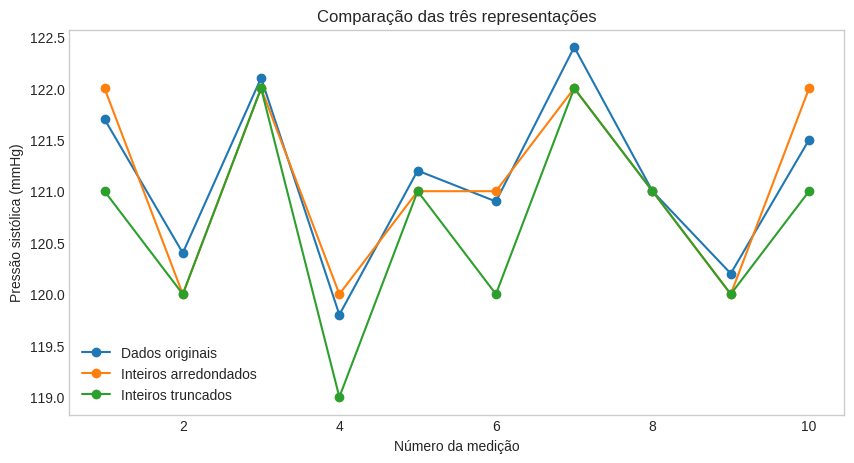

In [17]:
medicoes = range(1, 11)

plt.figure(figsize=(10, 5))

plt.plot(
    medicoes,
    dados_originais,
    marker="o",
    label="Dados originais"
)

plt.plot(
    medicoes,
    dados_int_round,
    marker="o",
    label="Inteiros arredondados"
)

plt.plot(
    medicoes,
    dados_int_trunc,
    marker="o",
    label="Inteiros truncados"
)


plt.xlabel("Número da medição")

plt.ylabel("Pressão sistólica (mmHg)")

plt.title("Comparação das três representações")

plt.legend()

plt.grid()

plt.show()

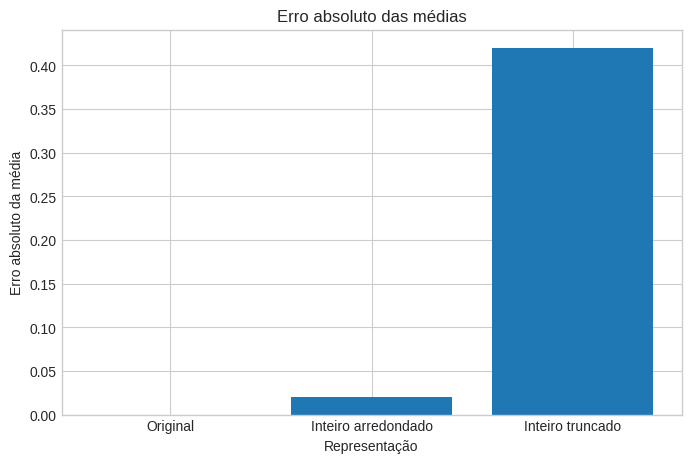

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    nomes,
    erros_absolutos
)

plt.xlabel("Representação")

plt.ylabel("Erro absoluto da média")

plt.title("Erro absoluto das médias")

plt.show()

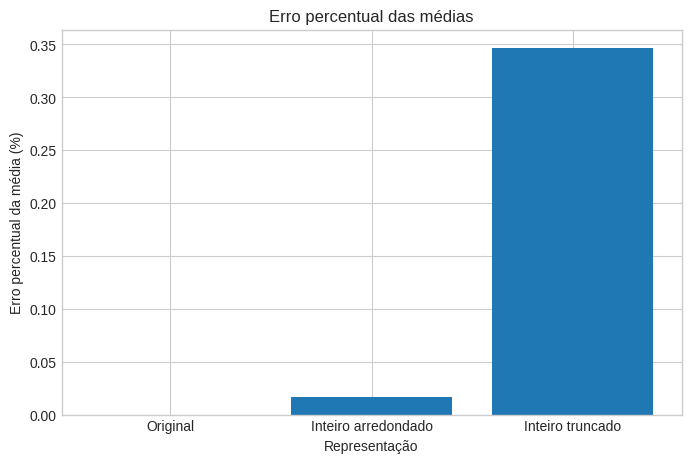

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    nomes,
    erros_percentuais
)

plt.xlabel("Representação")

plt.ylabel("Erro percentual da média (%)")

plt.title("Erro percentual das médias")

plt.show()

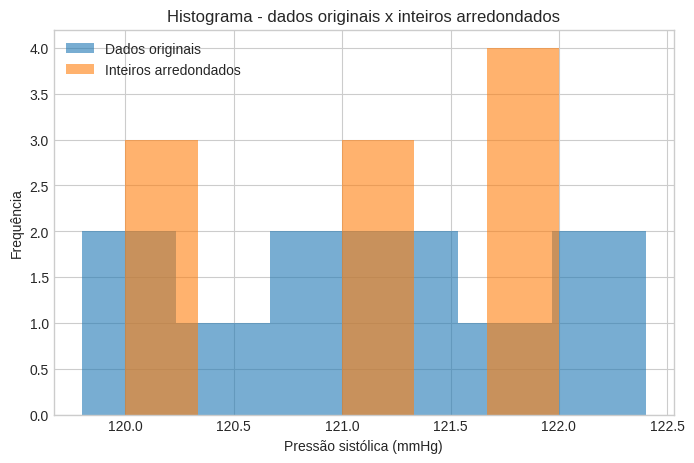

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(dados_originais, bins=6, alpha=0.6, label="Dados originais")

plt.hist(dados_int_round, bins=6, alpha=0.6, label="Inteiros arredondados")

plt.xlabel("Pressão sistólica (mmHg)")

plt.ylabel("Frequência")

plt.title("Histograma - dados originais x inteiros arredondados")

plt.legend()

plt.show()

### A representação inteira é suficiente?

A média fica bem preservada quando os dados são arredondados para inteiro, já que o erro percentual fica pequeno (menos de 1%). Porém a variabilidade real da amostra é perdida: como as medidas variam em torno de 1 a 2 mmHg entre si, arredondar para inteiro faz vários valores diferentes caírem no mesmo número, reduzindo o desvio-padrão observado. Para essa amostra pequena, a representação inteira serve para ter uma ideia geral da média, mas não é suficiente para preservar a variabilidade fina entre as medições.

## 5. Parte C - vazão em um tubo de pequeno diâmetro

Relação de Hagen-Poiseuille:

$$Q = \dfrac{\pi r^4 \Delta p}{8 \mu L}$$

Valores adotados: r = 0,80 mm, L = 0,20 m, µ = 3,5x10⁻³ Pa s, Δp = 1200 Pa.

In [21]:
def vazao_poiseuille(r, dp, mu, L):
  return (math.pi * (r ** 4) * dp) / (8 * mu * L)

In [22]:
r_ref = 0.80e-3 # m
L_ref = 0.20 # m
mu_ref = 3.5e-3# Pa s
dp_ref = 1200# Pa

Q_ref = vazao_poiseuille(r_ref, dp_ref, mu_ref, L_ref)

print(f"Q_ref = {Q_ref:.6e} m^3/s")


Q_ref = 2.757421e-07 m^3/s


### C.1 Precisão das variáveis


In [23]:
r_mm = 0.80

r_round_1 = round(r_mm, 1)
r_trunc_1 = truncar(r_mm, 1)

mu_round_3 = round(mu_ref, 3)
mu_trunc_3 = truncar(mu_ref, 3)

dp_round_100 = round(dp_ref / 100) * 100
dp_trunc_100 = math.trunc(dp_ref / 100) * 100

print("r arredondado =", r_round_1, "mm | r truncado =", r_trunc_1, "mm")
print("mu arredondado =", mu_round_3, "| mu truncado =", mu_trunc_3)
print("dp arredondado =", dp_round_100, "| dp truncado =", dp_trunc_100)


r arredondado = 0.8 mm | r truncado = 0.8 mm
mu arredondado = 0.004 | mu truncado = 0.003
dp arredondado = 1200 | dp truncado = 1200


In [24]:
cenarios = {
    "Todos os valores originais": (r_ref, dp_ref, mu_ref, L_ref),
    "r arredondado": (r_round_1 * 1e-3, dp_ref, mu_ref, L_ref),
    "r truncado": (r_trunc_1 * 1e-3, dp_ref, mu_ref, L_ref),
    "mu arredondado": (r_ref, dp_ref, mu_round_3, L_ref),
    "mu truncado": (r_ref, dp_ref, mu_trunc_3, L_ref),
    "dp arredondado": (r_ref, dp_round_100, mu_ref, L_ref),
    "dp truncado": (r_ref, dp_trunc_100, mu_ref, L_ref),
    "todas arredondadas": (r_round_1 * 1e-3, dp_round_100, mu_round_3, L_ref),
    "todas truncadas": (r_trunc_1 * 1e-3, dp_trunc_100, mu_trunc_3, L_ref),
}

for nome, (r, dp, mu, L) in cenarios.items():

    Q = vazao_poiseuille(r, dp, mu, L)

    ea = erro_absoluto(Q_ref, Q)
    er = erro_relativo(ea, Q_ref)
    ep = erro_percentual(er)

    print("\n", nome)
    print(f"Q = {Q:.6e} m^3/s")
    print(f"Ea = {ea:.6e}")
    print(f"Er = {er:.6e}")
    print(f"E% = {ep:.6f}")



 Todos os valores originais
Q = 2.757421e-07 m^3/s
Ea = 0.000000e+00
Er = 0.000000e+00
E% = 0.000000

 r arredondado
Q = 2.757421e-07 m^3/s
Ea = 0.000000e+00
Er = 0.000000e+00
E% = 0.000000

 r truncado
Q = 2.757421e-07 m^3/s
Ea = 0.000000e+00
Er = 0.000000e+00
E% = 0.000000

 mu arredondado
Q = 2.412743e-07 m^3/s
Ea = 3.446776e-08
Er = 1.250000e-01
E% = 12.500000

 mu truncado
Q = 3.216991e-07 m^3/s
Ea = 4.595701e-08
Er = 1.666667e-01
E% = 16.666667

 dp arredondado
Q = 2.757421e-07 m^3/s
Ea = 0.000000e+00
Er = 0.000000e+00
E% = 0.000000

 dp truncado
Q = 2.757421e-07 m^3/s
Ea = 0.000000e+00
Er = 0.000000e+00
E% = 0.000000

 todas arredondadas
Q = 2.412743e-07 m^3/s
Ea = 3.446776e-08
Er = 1.250000e-01
E% = 12.500000

 todas truncadas
Q = 3.216991e-07 m^3/s
Ea = 4.595701e-08
Er = 1.666667e-01
E% = 16.666667


### C.2 Sensibilidade

In [25]:
raios_mm = np.arange(0.70, 0.901, 0.01)

Q_referencia_lista = []
Q_arred_lista = []
Q_trunc_lista = []

for r_mm_i in raios_mm:

    r_m = r_mm_i * 1e-3
    Q_ref_i = vazao_poiseuille(r_m, dp_ref, mu_ref, L_ref)

    r_round_i = round(r_mm_i, 1) * 1e-3
    Q_round_i = vazao_poiseuille(r_round_i, dp_ref, mu_ref, L_ref)

    r_trunc_i = truncar(r_mm_i, 1) * 1e-3
    Q_trunc_i = vazao_poiseuille(r_trunc_i, dp_ref, mu_ref, L_ref)

    Q_referencia_lista.append(Q_ref_i)
    Q_arred_lista.append(Q_round_i)
    Q_trunc_lista.append(Q_trunc_i)


In [26]:
erros_abs_arred = []
erros_rel_arred = []
erros_per_arred = []

erros_abs_trunc = []
erros_rel_trunc = []
erros_per_trunc = []

for i in range(len(raios_mm)):

    ea_a = erro_absoluto(Q_referencia_lista[i], Q_arred_lista[i])
    er_a = erro_relativo(ea_a, Q_referencia_lista[i])
    ep_a = erro_percentual(er_a)

    ea_t = erro_absoluto(Q_referencia_lista[i], Q_trunc_lista[i])
    er_t = erro_relativo(ea_t, Q_referencia_lista[i])
    ep_t = erro_percentual(er_t)

    erros_abs_arred.append(ea_a)
    erros_rel_arred.append(er_a)
    erros_per_arred.append(ep_a)

    erros_abs_trunc.append(ea_t)
    erros_rel_trunc.append(er_t)
    erros_per_trunc.append(ep_t)


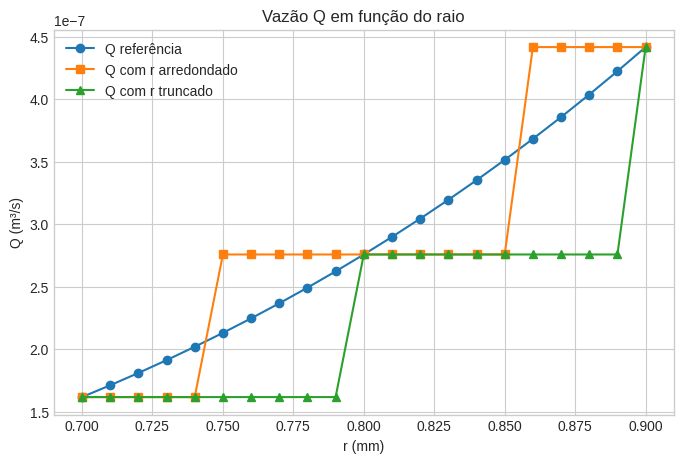

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(raios_mm, Q_referencia_lista, marker="o", label="Q referência")
plt.plot(raios_mm, Q_arred_lista, marker="s", label="Q com r arredondado")
plt.plot(raios_mm, Q_trunc_lista, marker="^", label="Q com r truncado")

plt.xlabel("r (mm)")
plt.ylabel("Q (m³/s)")
plt.title("Vazão Q em função do raio")
plt.legend()
plt.show()


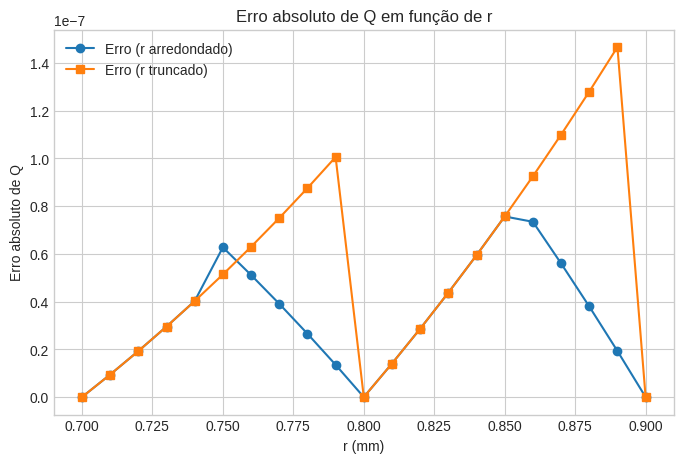

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(raios_mm, erros_abs_arred, marker="o", label="Erro (r arredondado)")
plt.plot(raios_mm, erros_abs_trunc, marker="s", label="Erro (r truncado)")

plt.xlabel("r (mm)")
plt.ylabel("Erro absoluto de Q")
plt.title("Erro absoluto de Q em função de r")
plt.legend()
plt.show()


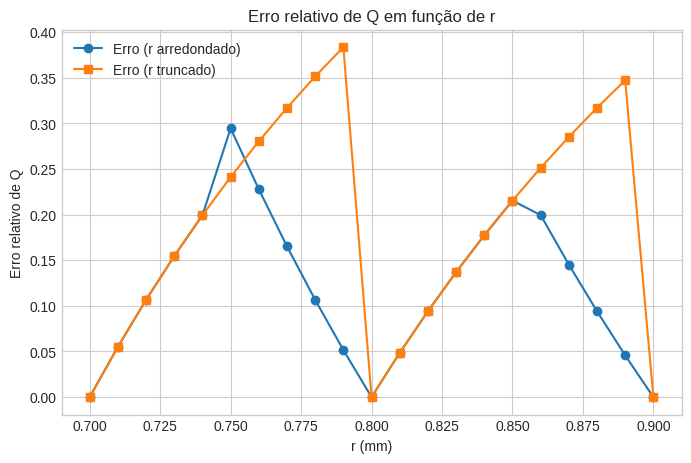

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(raios_mm, erros_rel_arred, marker="o", label="Erro (r arredondado)")
plt.plot(raios_mm, erros_rel_trunc, marker="s", label="Erro (r truncado)")

plt.xlabel("r (mm)")
plt.ylabel("Erro relativo de Q")
plt.title("Erro relativo de Q em função de r")
plt.legend()
plt.show()


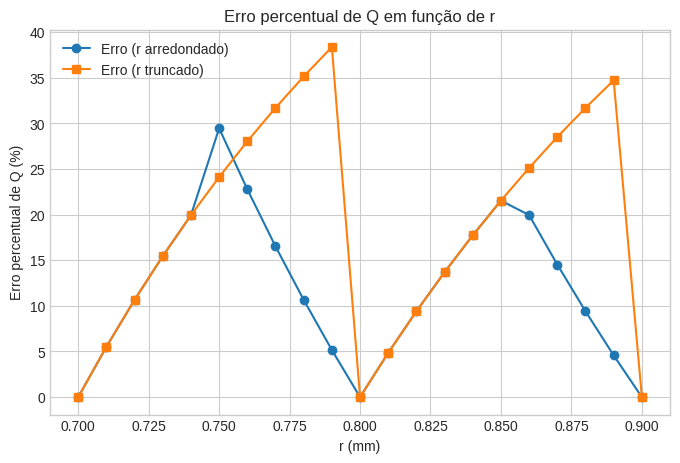

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(raios_mm, erros_per_arred, marker="o", label="Erro (r arredondado)")
plt.plot(raios_mm, erros_per_trunc, marker="s", label="Erro (r truncado)")

plt.xlabel("r (mm)")
plt.ylabel("Erro percentual de Q (%)")
plt.title("Erro percentual de Q em função de r")
plt.legend()
plt.show()


### Por que o erro no raio é amplificado?

Como Q depende de r elevado à 4, um pequeno erro relativo no raio é aproximadamente multiplicado por 4 no erro relativo da vazão (ΔQ/Q ≈ 4·Δr/r). Por isso, mesmo pequenas variações de arredondamento ou truncamento no raio geram erros bem maiores na vazão calculada.

## 6. Parte D - escoamento em um nanocateter

Modelo didático de nanocateter cilíndrico: r = 50 nm, L = 10 µm, µ = 3,5x10⁻³ Pa s, Δp = 5000 Pa.

In [31]:
r_nano = 50e-9 # m
L_nano = 10e-6 # m
mu_nano = 3.5e-3 # Pa s
dp_nano = 5000 # Pa

Q_nano = vazao_poiseuille(r_nano, dp_nano, mu_nano, L_nano)

print(f"Q_nano = {Q_nano:.6e} m^3/s")


Q_nano = 3.506242e-19 m^3/s


### D.1 Erro geométrico

In [32]:
delta_r_nm = np.arange(0.1, 5.01, 0.1)

Q_menos_lista = []
Q_mais_lista = []

erros_abs_max = []
erros_rel_max = []
erros_per_max = []

for dr_nm in delta_r_nm:

    dr_m = dr_nm * 1e-9

    r_menos = r_nano - dr_m
    r_mais = r_nano + dr_m

    Q_menos = vazao_poiseuille(r_menos, dp_nano, mu_nano, L_nano)
    Q_mais = vazao_poiseuille(r_mais, dp_nano, mu_nano, L_nano)

    ea_menos = erro_absoluto(Q_nano, Q_menos)
    ea_mais = erro_absoluto(Q_nano, Q_mais)
    ea_max = max(ea_menos, ea_mais)

    er_max = erro_relativo(ea_max, Q_nano)
    ep_max = erro_percentual(er_max)

    Q_menos_lista.append(Q_menos)
    Q_mais_lista.append(Q_mais)

    erros_abs_max.append(ea_max)
    erros_rel_max.append(er_max)
    erros_per_max.append(ep_max)


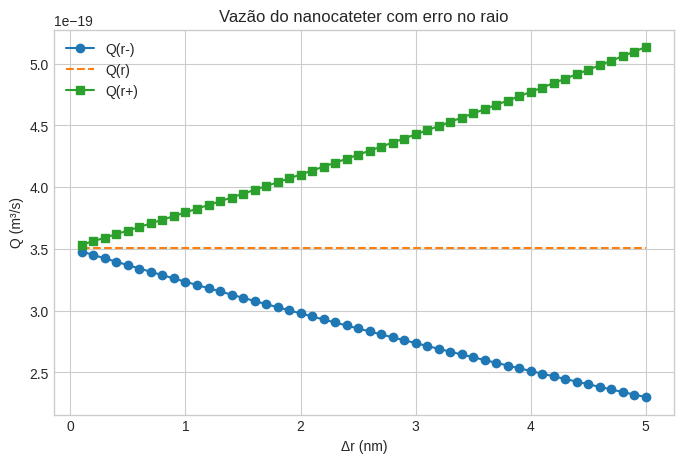

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(delta_r_nm, Q_menos_lista, marker="o", label="Q(r-)")
plt.plot(delta_r_nm, [Q_nano] * len(delta_r_nm), linestyle="--", label="Q(r)")
plt.plot(delta_r_nm, Q_mais_lista, marker="s", label="Q(r+)")

plt.xlabel("Δr (nm)")
plt.ylabel("Q (m³/s)")
plt.title("Vazão do nanocateter com erro no raio")
plt.legend()
plt.show()


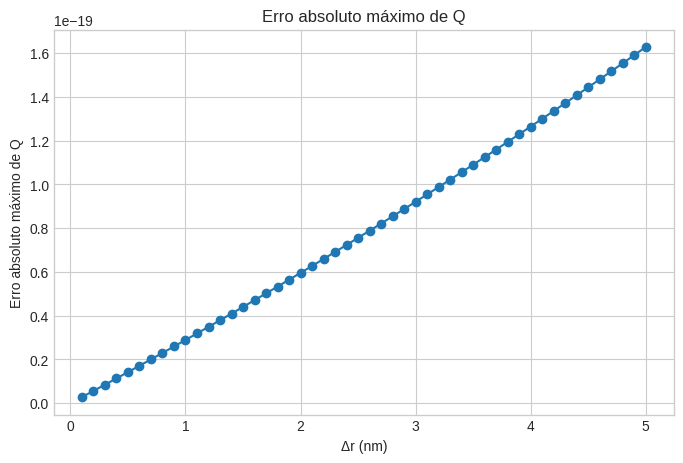

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(delta_r_nm, erros_abs_max, marker="o")

plt.xlabel("Δr (nm)")
plt.ylabel("Erro absoluto máximo de Q")
plt.title("Erro absoluto máximo de Q")
plt.show()


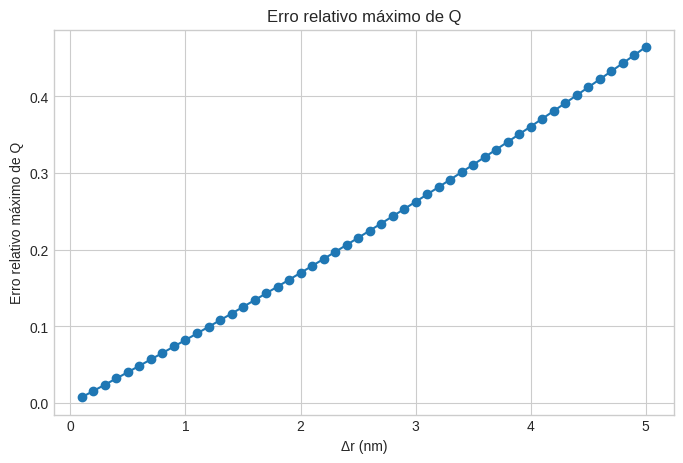

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(delta_r_nm, erros_rel_max, marker="o")

plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo máximo de Q")
plt.title("Erro relativo máximo de Q")
plt.show()


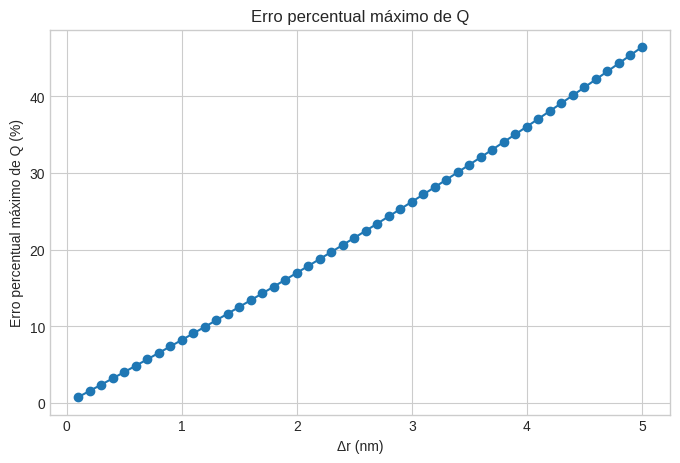

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(delta_r_nm, erros_per_max, marker="o")

plt.xlabel("Δr (nm)")
plt.ylabel("Erro percentual máximo de Q (%)")
plt.title("Erro percentual máximo de Q")
plt.show()


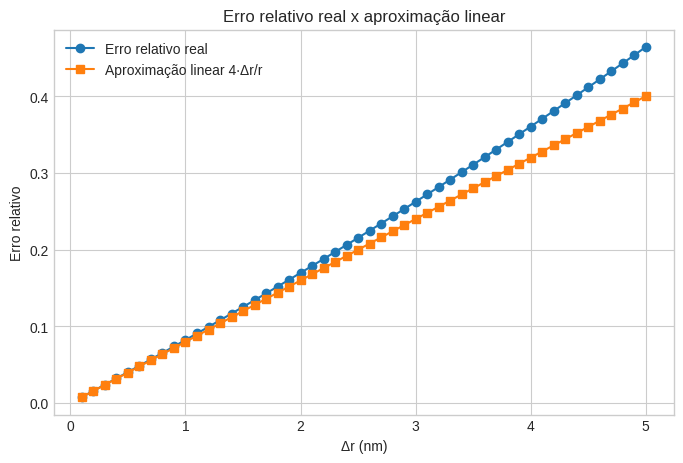

In [37]:
aprox_linear = 4 * (delta_r_nm * 1e-9) / r_nano

plt.figure(figsize=(8, 5))

plt.plot(delta_r_nm, erros_rel_max, marker="o", label="Erro relativo real")
plt.plot(delta_r_nm, aprox_linear, marker="s", label="Aproximação linear 4·Δr/r")

plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo")
plt.title("Erro relativo real x aproximação linear")
plt.legend()
plt.show()


A aproximação linear ΔQ/Q ≈ 4·Δr/r fica muito próxima do erro relativo real para Δr pequeno em relação a r, confirmando que o expoente 4 domina a sensibilidade de Q ao raio nessa escala.

### D.2 Precisão computacional

In [38]:
r32 = np.float32(r_nano)
r64 = np.float64(r_nano)

r4_32 = r32 ** 4
r4_64 = r64 ** 4

Q_32 = vazao_poiseuille(r32, np.float32(dp_nano), np.float32(mu_nano), np.float32(L_nano))
Q_64 = vazao_poiseuille(r64, np.float64(dp_nano), np.float64(mu_nano), np.float64(L_nano))

diferenca_abs = abs(Q_64 - Q_32)
diferenca_rel = diferenca_abs / abs(Q_64)

print("r^4 float32 =", r4_32)
print("r^4 float64 =", r4_64)
print("Q float32 =", Q_32)
print("Q float64 =", Q_64)
print("Diferença absoluta =", diferenca_abs)
print("Diferença relativa =", diferenca_rel)
print("eps float32 =", np.finfo(np.float32).eps)
print("eps float64 =", np.finfo(np.float64).eps)


r^4 float32 = 6.2500004e-30
r^4 float64 = 6.249999999999999e-30
Q float32 = 3.5062423e-19
Q float64 = 3.506241800881465e-19
Diferença absoluta = 5.228627689184328e-26
Diferença relativa = 1.4912342006389455e-07
eps float32 = 1.1920929e-07
eps float64 = 2.220446049250313e-16


In [39]:
dr_fracoes = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

for dr_frac in dr_fracoes:

    dr_m = dr_frac * r_nano

    Q_r = vazao_poiseuille(r_nano, dp_nano, mu_nano, L_nano)
    Q_r_dr = vazao_poiseuille(r_nano + dr_m, dp_nano, mu_nano, L_nano)

    delta1 = (Q_r_dr - Q_r) / Q_r

    delta2 = (1 + dr_frac) ** 4 - 1

    print("\nΔr/r =", dr_frac)
    print(f"delta1 = {delta1:.10e}")
    print(f"delta2 = {delta2:.10e}")
    print(f"diferença entre delta1 e delta2 = {abs(delta1 - delta2):.10e}")



Δr/r = 0.01
delta1 = 4.0604010000e-02
delta2 = 4.0604010000e-02
diferença entre delta1 e delta2 = 3.6082248300e-16

Δr/r = 0.001
delta1 = 4.0060040010e-03
delta2 = 4.0060040010e-03
diferença entre delta1 e delta2 = 2.2377932840e-16

Δr/r = 0.0001
delta1 = 4.0006000400e-04
delta2 = 4.0006000400e-04
diferença entre delta1 e delta2 = 1.2956215961e-17

Δr/r = 1e-05
delta1 = 4.0000600004e-05
delta2 = 4.0000600004e-05
diferença entre delta1 e delta2 = 5.0116567797e-16

Δr/r = 1e-06
delta1 = 4.0000060000e-06
delta2 = 4.0000059998e-06
diferença entre delta1 e delta2 = 2.6111738775e-16

Δr/r = 1e-07
delta1 = 4.0000005972e-07
delta2 = 4.0000006019e-07
diferença entre delta1 e delta2 = 4.6127847297e-16


Para valores de Δr/r muito pequenos, delta1 é calculado como a subtração de dois números muito próximos (Q(r+Δr) e Q(r)) dividida por um número pequeno, o que pode gerar perda de significância por cancelamento. Já delta2 evita essa subtração direta, sendo mais estável numericamente quando Δr/r é muito pequeno.

### D.3 Fenômeno físico

Quando a escala do canal diminui de milímetros (Parte C) para nanômetros (Parte D), a razão entre a área da superfície e o volume do canal aumenta muito. Isso faz com que os efeitos viscosos e as interações do fluido com a parede do canal, que em escalas maiores são pouco relevantes, passem a dominar o comportamento do escoamento. Além disso, como Q depende de r elevado à quarta potência, pequenas incertezas na fabricação ou na medida do raio em escala nanométrica se traduzem em erros muito maiores na vazão. Por isso, um resultado numérico com muitas casas decimais pode estar aritmeticamente correto e, mesmo assim, não representar bem o fenômeno físico real, já que a precisão do cálculo não substitui a validade do modelo usado.

## 7. Parte E - síntese visual

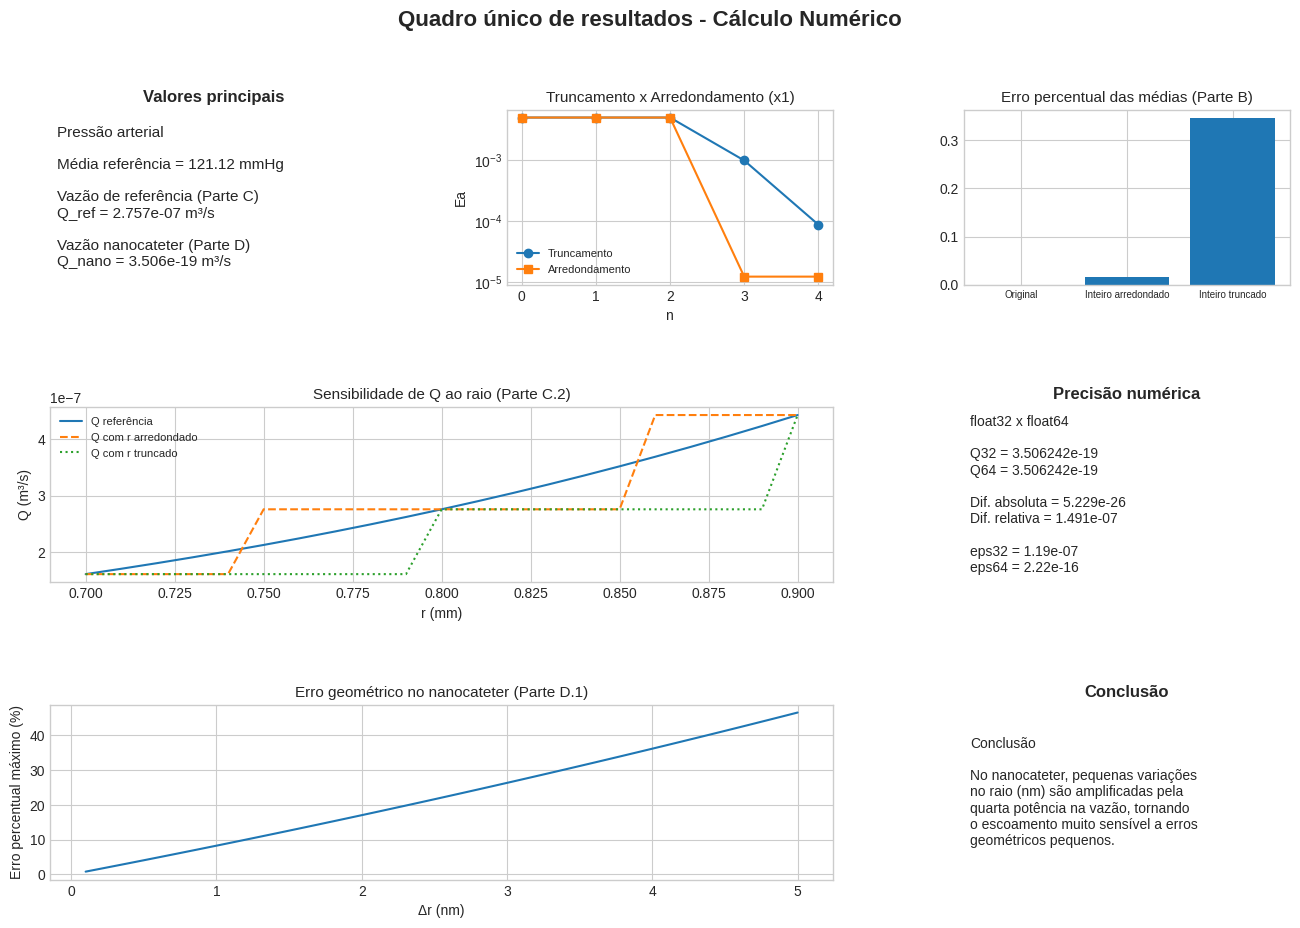

Imagem salva em quadro_resultados.png


In [40]:
fig = plt.figure(figsize=(16, 10), dpi=100)
gs = fig.add_gridspec(3, 3, hspace=0.7, wspace=0.4)

# cartao com valores principais
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis("off")
texto_cartao = (
    f"Pressão arterial\n\n"
    f"Média referência = {media_referencia:.2f} mmHg\n\n"
    f"Vazão de referência (Parte C)\n"
    f"Q_ref = {Q_ref:.3e} m³/s\n\n"
    f"Vazão nanocateter (Parte D)\n"
    f"Q_nano = {Q_nano:.3e} m³/s"
)

ax0.text(0.02, 0.5, texto_cartao, fontsize=11, va="center")
ax0.set_title("Valores principais", fontsize=12, fontweight="bold")

# truncamento x arredondamento
ax1 = fig.add_subplot(gs[0, 1])
ax1.semilogy(casas_decimais, erros_truncamento, marker="o", label="Truncamento")
ax1.semilogy(casas_decimais, erros_arredondamento, marker="s", label="Arredondamento")
ax1.set_xlabel("n")
ax1.set_ylabel("Ea")
ax1.set_title("Truncamento x Arredondamento (x1)", fontsize=11)
ax1.legend(fontsize=8)

# tres tipos de erro (pressao)
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(nomes, erros_percentuais)
ax2.set_title("Erro percentual das médias (Parte B)", fontsize=11)
ax2.tick_params(axis="x", labelsize=7)

# sensibilidade de Q ao raio
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(raios_mm, Q_referencia_lista, label="Q referência")
ax3.plot(raios_mm, Q_arred_lista, "--", label="Q com r arredondado")
ax3.plot(raios_mm, Q_trunc_lista, ":", label="Q com r truncado")
ax3.set_xlabel("r (mm)")
ax3.set_ylabel("Q (m³/s)")
ax3.set_title("Sensibilidade de Q ao raio (Parte C.2)", fontsize=11)
ax3.legend(fontsize=8)

# float32 x float64
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")
texto_float = (
    f"float32 x float64\n\n"
    f"Q32 = {Q_32:.6e}\n"
    f"Q64 = {Q_64:.6e}\n\n"
    f"Dif. absoluta = {diferenca_abs:.3e}\n"
    f"Dif. relativa = {diferenca_rel:.3e}\n\n"
    f"eps32 = {np.finfo(np.float32).eps:.2e}\n"
    f"eps64 = {np.finfo(np.float64).eps:.2e}"
)
ax4.text(0.02, 0.5, texto_float, fontsize=10, va="center")
ax4.set_title("Precisão numérica", fontsize=12, fontweight="bold")

# erro geometrico nanocateter
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(delta_r_nm, erros_per_max)
ax5.set_xlabel("Δr (nm)")
ax5.set_ylabel("Erro percentual máximo (%)")
ax5.set_title("Erro geométrico no nanocateter (Parte D.1)", fontsize=11)

# conclusao
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
texto_conclusao = (
    "Conclusão\n\n"
    "No nanocateter, pequenas variações\n"
    "no raio (nm) são amplificadas pela\n"
    "quarta potência na vazão, tornando\n"
    "o escoamento muito sensível a erros\n"
    "geométricos pequenos."
)
ax6.text(0.02, 0.5, texto_conclusao, fontsize=10, va="center")
ax6.set_title("Conclusão", fontsize=12, fontweight="bold")

fig.suptitle("Quadro único de resultados - Cálculo Numérico", fontsize=16, fontweight="bold")

plt.savefig("quadro_resultados.png", dpi=100)
plt.show()

print("Imagem salva em quadro_resultados.png")


## 8. GIF demonstrativo

In [42]:
import imageio.v2 as imageio
import io

raios_gif_nm = np.linspace(45, 55, 41)

raios_lista_gif = []
Q_lista_gif = []

frames = []

for r_atual_nm in raios_gif_nm:

    r_atual_m = r_atual_nm * 1e-9
    Q_atual = vazao_poiseuille(r_atual_m, dp_nano, mu_nano, L_nano)

    erro_perc_atual = erro_percentual(erro_relativo(erro_absoluto(Q_nano, Q_atual), Q_nano))

    raios_lista_gif.append(r_atual_nm)
    Q_lista_gif.append(Q_atual)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    circulo = plt.Circle((0, 0), r_atual_nm, color="steelblue")
    axs[0].add_patch(circulo)
    axs[0].set_xlim(-55, 55)
    axs[0].set_ylim(-55, 55)
    axs[0].set_aspect("equal")
    axs[0].set_title(f"r = {r_atual_nm:.2f} nm\nQ = {Q_atual:.3e} m³/s\nErro = {erro_perc_atual:.2f}%")

    axs[1].plot(raios_lista_gif, Q_lista_gif, marker="o")
    axs[1].set_xlim(45, 55)
    axs[1].set_xlabel("r (nm)")
    axs[1].set_ylabel("Q (m³/s)")
    axs[1].set_title("Curva Q x r")

    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format="png")
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("nanocateter.gif", frames, duration=0.15)

print("GIF salvo com", len(frames), "quadros")


GIF salvo com 41 quadros


In [44]:
from google.colab import files
files.download('quadro_resultados.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
from google.colab import files
files.download('nanocateter.gif')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Conclusão

Ao comparar o truncamento e arredondamento, é possível observar que o arredondamento no geral gera erros menores ou iguais ao do truncamento. Na análise das medidas de pressão arterial, a representação inteira preservou bem a média, mas diminui a variabilidade da amostra. Para o cálculo de vazão pela relação de Hagen-Poiseuille, pequenos erros de arredondamento e truncamento se propagam de forma amplificada para Q, por conta do expoente 4 no raio, o que se torna crítico em escalas muito pequenas, como no nanocateter. Para a comparação do float32 e float64, é possível ver que a precisão aritmética sozinha não garante que um resultado seja fisicamente adequado , reforçando que precisão numérica e validade do modelo físco são conceitos diferentes.
